In [46]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import math

def load_jsonl_motion(path):
    frames = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            frame = np.array(json.loads(line))  # shape [joints, 4]
            frames.append(frame)
    return np.array(frames)  # [frames, joints, 4]

def normalize_to_255(arr):
    vmin, vmax = arr.min(), arr.max()
    return ((arr - vmin) / (vmax - vmin + 1e-8) * 255).astype(np.uint8), vmin, vmax

def visualize_as_grid(input_path):
    files = []
    if os.path.isdir(input_path):
        for f in os.listdir(input_path):
            if f.endswith(".jsonl"):
                files.append(os.path.join(input_path, f))
    elif os.path.isfile(input_path) and input_path.endswith(".jsonl"):
        files = [input_path]
    else:
        raise ValueError("Input must be a .jsonl file or a folder containing .jsonl files")

    # --- Preload motions & stats ---
    motions = []
    all_xyz = []
    for file in files:
        motion = load_jsonl_motion(file)
        motions.append((file, motion))
        all_xyz.append(motion[:, :, :3].reshape(-1))
    all_xyz = np.concatenate(all_xyz)
    _, vmin, vmax = normalize_to_255(all_xyz)

    print(f"📊 Global XYZ range across all files: {vmin:.4f} → {vmax:.4f}")

    # --- Grid layout ---
    n = len(motions)
    cols = min(3, n)  # up to 3 per row
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i, (file, motion) in enumerate(motions):
        # Normalize xyz
        xyz = motion[:, :, :3].reshape(-1)
        xyz_norm, _, _ = normalize_to_255(xyz)
        xyz_norm = xyz_norm.reshape(motion.shape[0], motion.shape[1], 3)

        # Confidence as alpha
        alpha = np.clip(motion[:, :, 3], 0, 1)
        alpha = (alpha * 255).astype(np.uint8)

        # Build RGBA image [joints, frames, 4]
        rgba = np.concatenate([xyz_norm, alpha[..., None]], axis=-1)
        img = np.transpose(rgba, (1, 0, 2))

        ax = axes[i]
        ax.imshow(img)
        ax.set_title(os.path.basename(file), fontsize=9)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Joints")

    # Hide extra axes if grid bigger than number of files
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import os, math

def load_npy_motion(path):
    """
    Load a .npy motion file into shape [frames, joints, 3].
    """
    motion = np.load(path)
    if motion.ndim == 2:  # flattened [frames, joints*3]
        njoints = motion.shape[1] // 3
        motion = motion.reshape(motion.shape[0], njoints, 3)
    return motion  # [frames, joints, 3]

def visualize_npy_grid(input_path):
    """
    Visualize one or more .npy motion files as images.
    Each file is one subplot. X-axis = Frames, Y-axis = Joints.
    """
    files = []
    if os.path.isdir(input_path):
        for root, _, fs in os.walk(input_path):
            for f in fs:
                if f.endswith(".npy"):
                    files.append(os.path.join(root, f))
    elif os.path.isfile(input_path) and input_path.endswith(".npy"):
        files = [input_path]
    else:
        raise ValueError("Input must be a .npy file or a folder containing .npy files")

    motions = [load_npy_motion(f) for f in files]

    # Normalize across all motions
    all_xyz = np.concatenate([m.reshape(-1, 3) for m in motions])
    vmin, vmax = all_xyz.min(), all_xyz.max()
    print(f"📊 Global XYZ range across all files: {vmin:.4f} → {vmax:.4f}")

    n = len(motions)
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i, (file, motion) in enumerate(zip(files, motions)):
        # Normalize xyz to 0–255
        xyz = motion.reshape(-1)
        xyz_norm = ((xyz - vmin) / (vmax - vmin + 1e-8) * 255).astype(np.uint8)
        xyz_norm = xyz_norm.reshape(motion.shape[0], motion.shape[1], 3)

        # Add opaque alpha channel
        alpha = np.ones((motion.shape[0], motion.shape[1], 1), dtype=np.uint8) * 255
        rgba = np.concatenate([xyz_norm, alpha], axis=-1)  # [frames, joints, 4]

        # Convert to image format [joints, frames, RGBA]
        img = np.transpose(rgba, (1, 0, 2))

        # Title = relative path without filename
        parts = os.path.normpath(file).split(os.sep)
        # Example parts: [..., 'p005-sandwich-salad-baking-monoply-boxing', 'keypoints_3d', '018', 'xyz_both.npy']
        if len(parts) >= 4:
            scene = parts[-4]  # e.g. "p005-sandwich-salad-baking-monoply-boxing"
            seq   = parts[-2]  # e.g. "018"
            title = f"{scene}\\{seq}"
        else:
            title = os.path.basename(os.path.dirname(file))

        if not title:
            title = os.path.basename(os.path.dirname(file))

        # Plot
        ax = axes[i]
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Joints")

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


📊 Global XYZ range across all files: 0.0090 → 0.6804


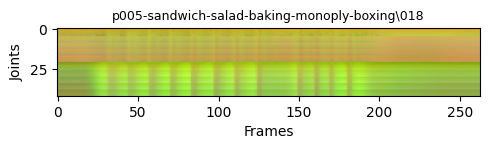

📊 Global XYZ range across all files: 0.1398 → 0.6986


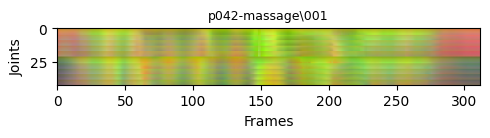

In [48]:
# # Folder with original training motions
# visualize_npy_grid(r"D:\repos\refactored_MDM\GigaHands_Data\coverted_motions\hand_poses_xyz")

# Or single motion file
visualize_npy_grid(
    r"D:\repos\refactored_MDM\GigaHands_Data\coverted_motions\hand_poses_xyz\p005-sandwich-salad-baking-monoply-boxing\keypoints_3d\018\xyz_both.npy"
)

visualize_npy_grid(
    r"D:\repos\refactored_MDM\GigaHands_Data\coverted_motions\hand_poses_xyz\p042-massage\keypoints_3d\001\xyz_both.npy"
)


📊 Global XYZ range across all files: 0.1181 → 0.6759


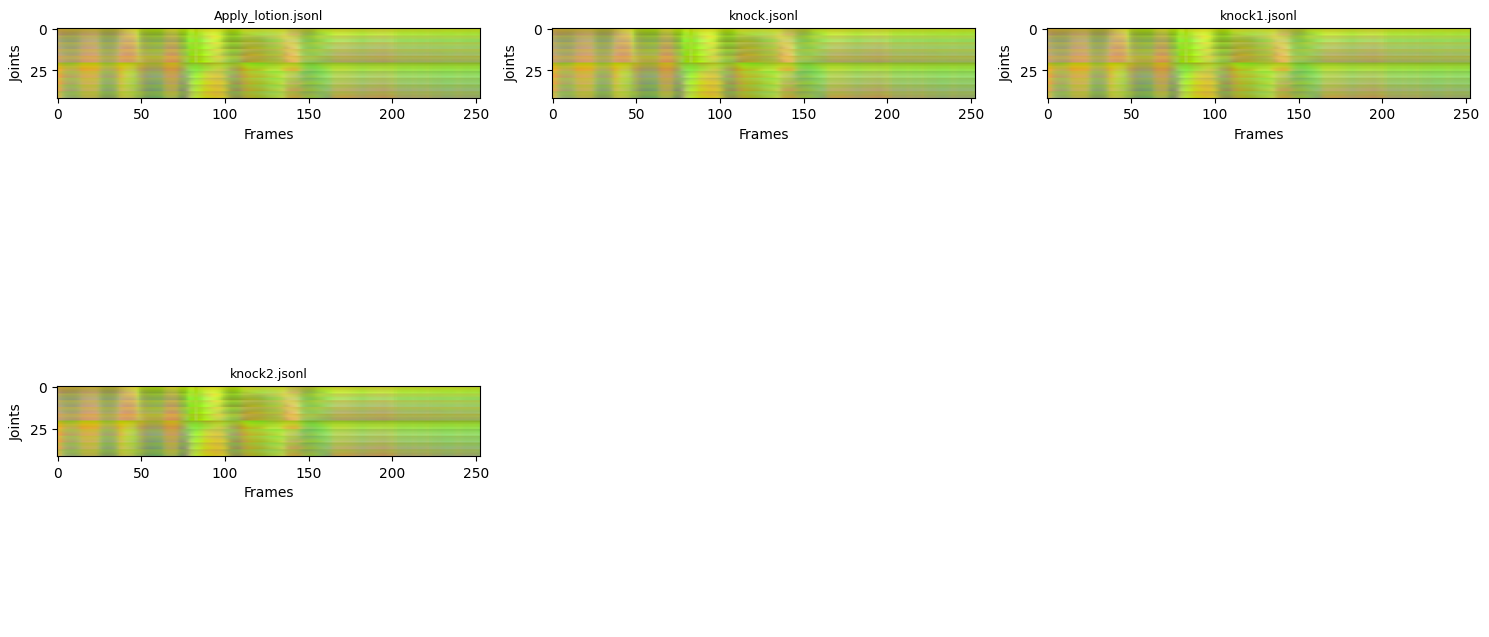

📊 Global XYZ range across all files: -0.1773 → 0.0868


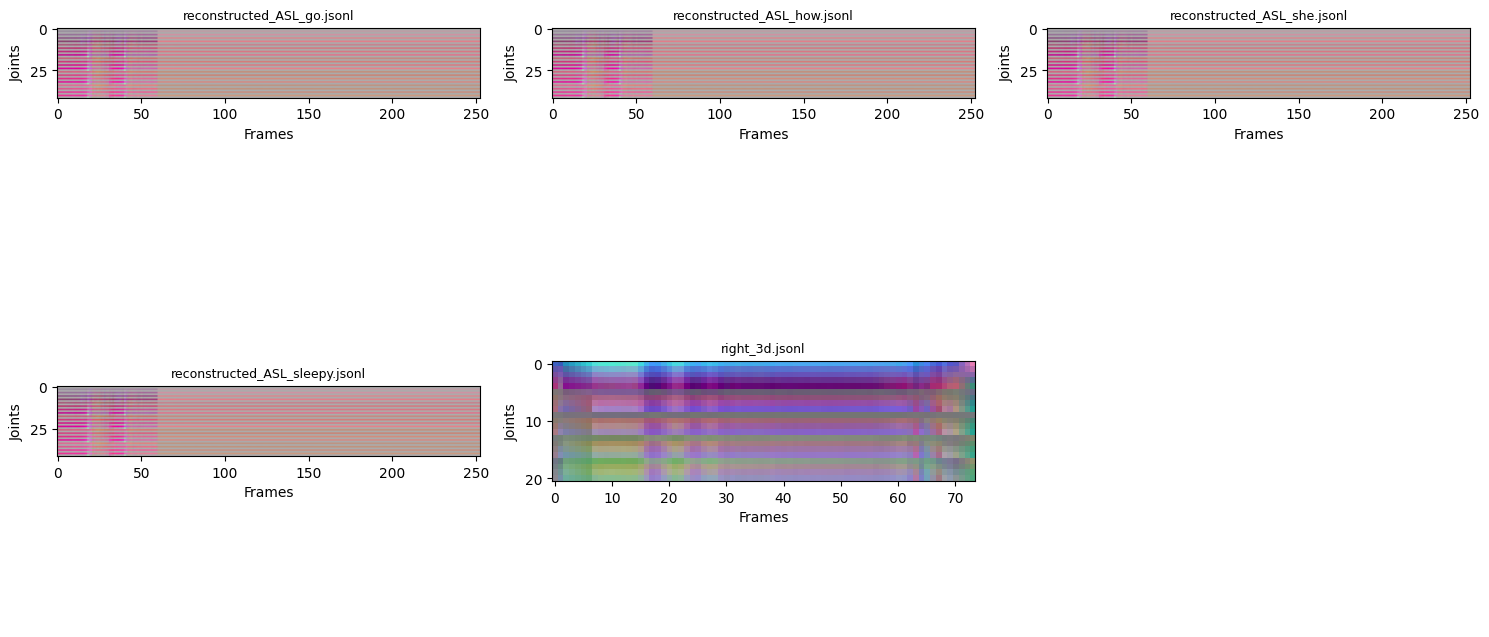

📊 Global XYZ range across all files: -1.8433 → 3.0148


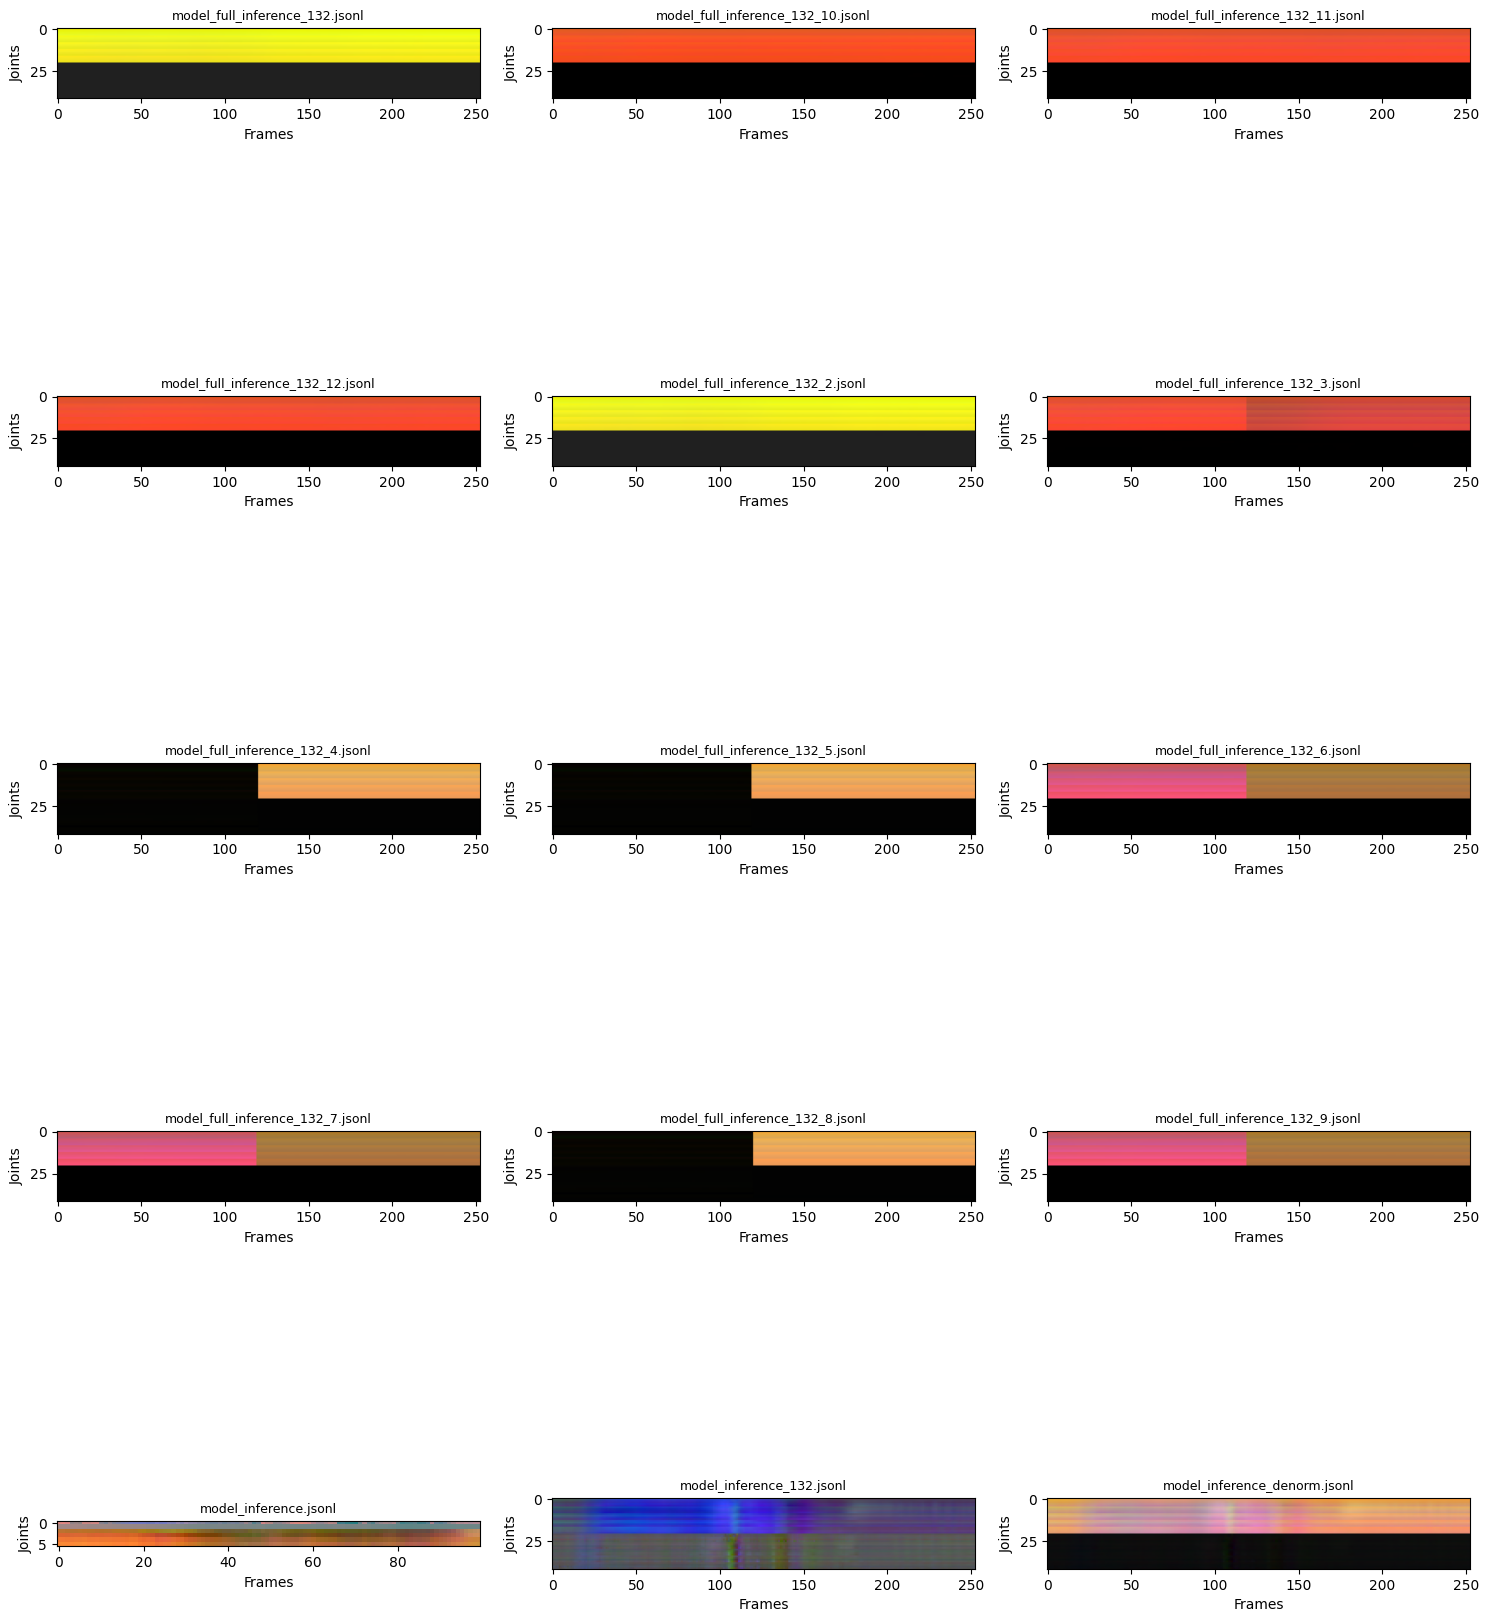

In [49]:

# 🔧 Example usage:
visualize_as_grid(r"D:\repos\Hand_Motion_Viewer\public\gigahands_dual")
# or with a folder:
# visualize_motions(["/mnt/data/motion_folder"])


visualize_as_grid(r"D:\repos\Hand_Motion_Viewer\public\asl")

visualize_as_grid(r"D:\repos\Hand_Motion_Viewer\public\gigahands")
